# Brain–Transformer Equivalence: Corrected Empirical Pipeline
**Dataset**: Plomecka et al. (2022) ZuCo NR Task — [osf.io/2abup](https://osf.io/2abup)  
**Model**: GPT-2 (12 transformer layers)  
**Core test**: Stimulus-level RSA between EEG representations and GPT-2 hidden states across all layers.

### What changed from v1
| Previous (broken) | This version (correct) |
|---|---|
| RSA on K-Means centroids (45 pairs) | Stimulus-level RDMs (N×N, all sentence pairs) |
| Single GPT-2 layer | Layer-by-layer RSA curve (0–12) |
| No stimulus alignment | EEG ↔ GPT-2 paired by sentence ID |
| Raw FFD flatten | Time-windowed EEG (4 windows, 200–600ms primary) |
| Hardcoded layer-wise ρ | Computed from data + permutation test |


In [12]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
_ = user_secrets.get_secret("HF_TOKEN")

import os, glob, csv as csv_module, warnings
import h5py
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import GPT2Tokenizer, GPT2Model
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2', output_hidden_states=True).to(device)
model.eval()
N_LAYERS = 12  # transformer blocks; index 0 = embedding layer
print(f"GPT-2 loaded ({N_LAYERS} transformer layers + embedding).")

Device: cpu


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 loaded (12 transformer layers + embedding).


## Step 1 — Build Sentence Map (.mat loading)

In [43]:
# ── REPLACEMENT: Step 1 — Build sentence map directly from .mat files ─────────
# No CSV dependency. Extract all unique sentences across all participants.

from difflib import SequenceMatcher

mat_files = glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat')
sentence_map = {}   # s_id (int) → sentence text
text_to_id   = {}  # sentence_text (normalised) → s_id
next_id      = [0]

def normalise(text):
    return ' '.join(text.strip().lower().split())

def get_or_create_id(sentence_text):
    key = normalise(sentence_text)
    if key not in text_to_id:
        text_to_id[key] = next_id[0]
        sentence_map[next_id[0]] = sentence_text.strip()
        next_id[0] += 1
    return text_to_id[key]

print("--- Building sentence map from .mat files ---")
for m_path in sorted(mat_files):
    p_id = os.path.basename(m_path).split('_')[0].replace('results', '')
    with h5py.File(m_path, 'r') as f:
        sd = f['sentenceData']
        for i in range(len(sd['content'])):
            try:
                raw  = f[sd['content'][i, 0]][:]
                text = ''.join([chr(int(c)) for c in raw.flatten()]).strip()
                if text:
                    get_or_create_id(text)
            except:
                continue

print(f"Total unique sentences: {len(sentence_map)}")
print(f"Sample IDs: {list(sentence_map.items())[:3]}")

--- Building sentence map from .mat files ---
Total unique sentences: 344
Sample IDs: [(0, 'Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promote human welfare.'), (1, 'After this initial success, Ford left Edison Illuminating and, with other investors, formed the Detroit Automobile Company.'), (2, 'With his interest in race cars, he formed a second company, the Henry Ford Company.')]


## Step 2 — Extract GPT-2 Hidden States (all layers, all sentences)
For each sentence: tokenise → forward pass → **mean-pool across tokens** at every layer.  
This gives one 768-dim vector per (sentence, layer) — the LLM's *s_k* state.

> **Why mean-pool?** Sentence-level EEG has no natural token alignment,
> so we collapse the token axis to match the granularity of the EEG representation.

In [44]:
gpt2_states = {}  # s_id → list of 13 arrays, each shape (768,)
#                    index 0 = embedding, 1–12 = transformer layers

print("--- Extracting GPT-2 hidden states ---")
with torch.no_grad():
    for s_id, text in sentence_map.items():
        try:
            inputs = tokenizer(
                text, return_tensors='pt',
                truncation=True, max_length=128
            ).to(device)
            outputs = model(**inputs)
            # hidden_states: tuple of 13 tensors, each (1, n_tokens, 768)
            gpt2_states[s_id] = [
                outputs.hidden_states[layer][0].mean(dim=0).cpu().numpy()
                for layer in range(N_LAYERS + 1)
            ]
        except Exception as e:
            print(f"  s_id {s_id}: {e}")

print(f"Done. {len(gpt2_states)} sentences extracted.")
print(f"State vector shape: {gpt2_states[list(gpt2_states.keys())[0]][1].shape}")

--- Extracting GPT-2 hidden states ---
Done. 344 sentences extracted.
State vector shape: (768,)


## Step 3 — Extract EEG Features (time-windowed)

**ZuCo EEG specs**: 500 Hz, epochs typically −100 ms to +900 ms relative to fixation onset  
→ 500 samples. 105 EEG channels.

We define four time windows and extract **mean amplitude per channel** in each:

| Window | Samples (500 Hz, −100 ms baseline) | Cognitive process |
|---|---|---|
| `early` | 25–75 (0–100 ms) | Visual / orthographic |
| `P2` | 75–125 (100–200 ms) | Early lexical |
| `N400` | 150–350 (200–600 ms) | **Semantic** ← primary |
| `late` | 350–450 (600–800 ms) | Post-lexical integration |

Per sentence: word-level EEG vectors are **averaged across all words** to give a
sentence-level representation — matching the GPT-2 mean-pooled representation.

In [45]:
# ── REPLACEMENT: Step 3 — EEG extraction (frequency-band aware) ──────────────

# ZuCo FFD_tN: N = frequency band index (1=theta, 2=alpha, 3=beta, 4=gamma, 5=high-gamma)
FREQ_BANDS = {
    'theta':      'FFD_t1',
    'alpha':      'FFD_t2',
    'beta':       'FFD_t3',
    'gamma':      'FFD_t4',
    'high_gamma': 'FFD_t5',
}
PRIMARY_BAND = 'theta'

def extract_band_features(f, words_group, band_field):
    """
    Extract per-channel power for one frequency band across all words.
    Returns list of (105,) arrays — one per word.
    """
    if band_field not in words_group:
        return []
    ffd = words_group[band_field]
    vectors = []
    for w_idx in range(ffd.shape[0]):
        try:
            eeg_raw = np.array(f[ffd[w_idx, 0]])   # shape (105, 1) or (105,)
            vec = eeg_raw.flatten()                  # → (105,)
            if vec.size == 0 or np.all(np.isnan(vec)) or np.all(vec == 0):
                continue
            vec = np.nan_to_num(vec, nan=0.0)
            vectors.append(vec)
        except:
            continue
    return vectors

# bio_data[p_id][s_id] = dict: band_name → averaged (105,) vector across words
bio_data = {}
mat_files = glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat')
print(f"--- Extracting EEG ({len(mat_files)} participants, {len(FREQ_BANDS)} frequency bands) ---")

for m_path in sorted(mat_files):
    p_id = os.path.basename(m_path).split('_')[0].replace('results', '')
    bio_data[p_id] = {}

    try:
        with h5py.File(m_path, 'r') as f:
            sd = f['sentenceData']
            content_refs = sd['content']
            word_refs    = sd['word']

            for i in range(len(content_refs)):
                # sentence text → sentence ID
                try:
                    raw = f[content_refs[i, 0]][:]
                    sentence_text = ''.join([chr(int(c)) for c in raw.flatten()]).strip()
                except:
                    continue
                    
                key      = normalise(sentence_text)
                match_id = text_to_id.get(key, None)
                if match_id is None:
                    continue
                wg = f[word_refs[i, 0]]
                sentence_bands = {}

                for band_name, field in FREQ_BANDS.items():
                    word_vecs = extract_band_features(f, wg, field)
                    if word_vecs:
                        # Average across words → one (105,) vector per sentence
                        sentence_bands[band_name] = np.stack(word_vecs).mean(axis=0)

                if sentence_bands:
                    bio_data[p_id][match_id] = sentence_bands

        p_count = len(bio_data[p_id])
        # Show which bands were actually found
        if p_count > 0:
            sample = next(iter(bio_data[p_id].values()))
            bands_found = list(sample.keys())
        else:
            bands_found = []
        print(f"  {p_id}: {p_count} sentences, bands: {bands_found}")

    except Exception as e:
        print(f"  Error in {p_id}: {e}")

--- Extracting EEG (16 participants, 5 frequency bands) ---
  YAC: 245 sentences, bands: ['theta', 'alpha']
  YAG: 344 sentences, bands: ['theta', 'alpha']
  YAK: 246 sentences, bands: ['theta', 'alpha']
  YDG: 344 sentences, bands: ['theta', 'alpha']
  YDR: 344 sentences, bands: ['theta', 'alpha']
  YFR: 344 sentences, bands: ['theta', 'alpha']
  YFS: 344 sentences, bands: ['theta', 'alpha']
  YHS: 344 sentences, bands: ['theta', 'alpha']
  YIS: 344 sentences, bands: ['theta', 'alpha']
  YLS: 241 sentences, bands: ['theta', 'alpha']
  YMD: 344 sentences, bands: ['theta', 'alpha']
  YRK: 339 sentences, bands: ['theta', 'alpha']
  YRP: 343 sentences, bands: ['theta', 'alpha']
  YSD: 344 sentences, bands: ['theta', 'alpha']
  YSL: 344 sentences, bands: ['theta', 'alpha']
  YTL: 340 sentences, bands: ['theta', 'alpha']


## Step 4 — Find Shared Stimuli & Aggregate to Sentence Level
Keep sentences seen by ≥50% of participants **and** present in GPT-2 states.  
Aggregate: average word-level EEG vectors across all words in a sentence.

In [46]:
def aggregate_sentence_eeg(word_features_list, window):
    """Average word-level EEG vectors across words in a sentence."""
    vecs = [wf[window] for wf in word_features_list if window in wf]
    return np.stack(vecs).mean(axis=0) if vecs else None

all_participants = list(bio_data.keys())
sentence_counts  = {}
for p_id in all_participants:
    for s_id in bio_data[p_id]:
        sentence_counts[s_id] = sentence_counts.get(s_id, 0) + 1

min_p = max(1, len(all_participants) // 2)
shared_ids = sorted([
    sid for sid, cnt in sentence_counts.items()
    if cnt >= min_p and sid in gpt2_states
])

N = len(shared_ids)
id_to_idx = {sid: i for i, sid in enumerate(shared_ids)}
print(f"Shared stimuli: {N} sentences (seen by ≥{min_p}/{len(all_participants)} participants)")

Shared stimuli: 344 sentences (seen by ≥8/16 participants)


## Step 5 — Compute Representational Dissimilarity Matrices (RDMs)

**EEG RDM**: N×N cosine-distance matrix, averaged across participants  
(participant-averaged RDM is more stable; see Nili et al., 2014).

**GPT-2 RDMs**: One N×N RDM per layer (13 total). Each cell = cosine distance
between sentence representations *i* and *j* in that layer's geometry.

All feature matrices are z-scored before computing distances.

In [47]:
# ── REPLACEMENT: Step 5 — RDMs (per-band EEG, per-layer GPT-2) ───────────────

all_participants = list(bio_data.keys())

# Shared sentences
sentence_counts = {}
for p_id in all_participants:
    for s_id in bio_data[p_id]:
        sentence_counts[s_id] = sentence_counts.get(s_id, 0) + 1

min_p = max(1, len(all_participants) // 2)
shared_ids = sorted([
    sid for sid, cnt in sentence_counts.items()
    if cnt >= min_p and sid in gpt2_states
])
N = len(shared_ids)
id_to_idx = {sid: i for i, sid in enumerate(shared_ids)}
print(f"Shared stimuli: {N} sentences")

tri = np.triu_indices(N, k=1)

def build_eeg_rdm(band_name):
    """Build participant-averaged EEG RDM for one frequency band."""
    rdm_stack = np.full((len(all_participants), N, N), np.nan)

    for k, p_id in enumerate(all_participants):
        eeg_matrix, valid_ids = [], []
        for sid in shared_ids:
            if sid in bio_data[p_id] and band_name in bio_data[p_id][sid]:
                v = bio_data[p_id][sid][band_name]
                if not np.all(v == 0) and not np.all(np.isnan(v)):
                    eeg_matrix.append(v)
                    valid_ids.append(sid)

        if len(eeg_matrix) < 5:
            continue
        X = StandardScaler().fit_transform(np.stack(eeg_matrix))
        rdm_p = squareform(pdist(X, metric='cosine'))
        for i, si in enumerate(valid_ids):
            for j, sj in enumerate(valid_ids):
                rdm_stack[k, id_to_idx[si], id_to_idx[sj]] = rdm_p[i, j]

    return np.nanmean(rdm_stack, axis=0)

# Build EEG RDMs for all bands
RDM_bio = {}
for band in FREQ_BANDS:
    RDM_bio[band] = build_eeg_rdm(band)
    valid_pairs = (~np.isnan(RDM_bio[band][tri[0], tri[1]])).sum()
    print(f"  {band:>12}: {valid_pairs} valid RDM pairs / {len(tri[0])}")

# Build GPT-2 RDMs for all layers
RDM_ai = {}
for layer in range(N_LAYERS + 1):
    X_ai = np.stack([gpt2_states[sid][layer] for sid in shared_ids])
    X_ai = StandardScaler().fit_transform(X_ai)
    RDM_ai[layer] = squareform(pdist(X_ai, metric='cosine'))

print(f"\nGPT-2 RDMs: {N_LAYERS+1} layers, shape {RDM_ai[0].shape}")

Shared stimuli: 344 sentences
         theta: 58996 valid RDM pairs / 58996
         alpha: 58996 valid RDM pairs / 58996
          beta: 0 valid RDM pairs / 58996
         gamma: 0 valid RDM pairs / 58996
    high_gamma: 0 valid RDM pairs / 58996

GPT-2 RDMs: 13 layers, shape (344, 344)


In [48]:
# ── DIAGNOSTIC: trace the NaN chain ──────────────────────────────────────────
print("=== 1. bio_data summary ===")
for p_id in list(all_participants)[:3]:
    n_sentences = len(bio_data[p_id])
    in_shared   = sum(1 for sid in bio_data[p_id] if sid in id_to_idx)
    print(f"  {p_id}: {n_sentences} sentences total, {in_shared} in shared_ids")

print("\n=== 2. Sample word-feature inspection (first participant, first sentence) ===")
p0 = all_participants[0]
s0 = list(bio_data[p0].keys())[0]
wf0 = bio_data[p0][s0]
print(f"  Participant: {p0}, Sentence ID: {s0}")
print(f"  Word count: {len(wf0)}")
print(f"  First word feature keys: {list(wf0[0].keys()) if wf0 else 'EMPTY'}")
if wf0 and wf0[0]:
    first_key = list(wf0[0].keys())[0]
    print(f"  First window vector shape: {wf0[0][first_key].shape}")
    print(f"  N400 key present: {'N400' in wf0[0]}")
    if 'N400' in wf0[0]:
        v = wf0[0]['N400']
        print(f"  N400 vector stats: min={v.min():.4f}, max={v.max():.4f}, "
              f"NaN count={np.isnan(v).sum()}")

print("\n=== 3. aggregate_sentence_eeg output for first participant ===")
hit, miss_none, miss_nan = 0, 0, 0
for sid in shared_ids[:20]:
    if sid in bio_data[p0]:
        v = aggregate_sentence_eeg(bio_data[p0][sid], PRIMARY_WINDOW)
        if v is None:
            miss_none += 1
        elif np.isnan(v).any():
            miss_nan += 1
        else:
            hit += 1
print(f"  (first 20 shared sentences) hit={hit}, returns-None={miss_none}, has-NaN={miss_nan}")

print("\n=== 4. Raw EEG array shape check ===")
import h5py, glob
m_path = sorted(glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat'))[0]
with h5py.File(m_path, 'r') as f:
    sd = f['sentenceData']
    word_refs = sd['word']
    wg = f[word_refs[0, 0]]
    if 'FFD_t1' in wg:
        ffd = wg['FFD_t1']
        eeg_raw = np.array(f[ffd[0, 0]])
        print(f"  Raw EEG shape: {eeg_raw.shape}")
        print(f"  dtype: {eeg_raw.dtype}")

=== 1. bio_data summary ===
  YAC: 245 sentences total, 245 in shared_ids
  YAG: 344 sentences total, 344 in shared_ids
  YAK: 246 sentences total, 246 in shared_ids

=== 2. Sample word-feature inspection (first participant, first sentence) ===
  Participant: YAC, Sentence ID: 0
  Word count: 2


KeyError: 0

## Step 6 — Layer-wise RSA (Main Result)

Spearman correlation between the EEG RDM and each GPT-2 layer RDM.

**What to look for**: A monotonically increasing ρ across layers would be
direct evidence for the **time t ↔ depth ℓ mapping** proposed in the paper.
Even a non-monotonic curve with a peak at deep layers supports the claim that
the final transformer state is the most brain-like.

In [49]:
# Step 6 — use primary band
rdm_primary = RDM_bio[PRIMARY_BAND]
valid_mask = ~np.isnan(rdm_primary[tri[0], tri[1]])
bio_vec    =  rdm_primary[tri[0], tri[1]][valid_mask]
print(f"Valid RDM pairs: {valid_mask.sum()} / {len(valid_mask)}")

rsa_results = []
print(f"{'Layer':>7}  {'Spearman ρ':>11}  {'p-value':>12}  sig")
print("─" * 45)

for layer in range(N_LAYERS + 1):
    ai_vec    = RDM_ai[layer][tri[0], tri[1]][valid_mask]
    rho, p    = spearmanr(bio_vec, ai_vec)
    sig       = '*' if p < 0.05 else ('†' if p < 0.10 else '')
    label     = 'Embed' if layer == 0 else f'L{layer:02d}'
    print(f"{label:>7}   {rho:+.4f}       {p:.4e}   {sig}")
    rsa_results.append({'layer': layer, 'label': label, 'rho': rho, 'p': p})

rsa_df = pd.DataFrame(rsa_results)


# ── fix: drop NaN rows before idxmax ──────────────────────────────────────────
rsa_df_valid = rsa_df.dropna(subset=['rho'])
if rsa_df_valid.empty:
    print("\nWARNING: all RSA values are NaN — check EEG RDM")
    rdm_check = RDM_bio[PRIMARY_BAND]
    valid_pairs = (~np.isnan(rdm_check[tri[0], tri[1]])).sum()
    print(f"  {PRIMARY_BAND} RDM valid pairs: {valid_pairs} / {len(tri[0])}")
    print(f"  Available bands with data: "
          f"{[b for b in FREQ_BANDS if (~np.isnan(RDM_bio[b][tri[0], tri[1]])).sum() > 0]}")

Valid RDM pairs: 58996 / 58996
  Layer   Spearman ρ       p-value  sig
─────────────────────────────────────────────
  Embed   +0.0479       2.7973e-31   *
    L01   +0.0508       4.4617e-35   *
    L02   +0.0517       3.6005e-36   *
    L03   +0.0544       7.3523e-40   *
    L04   +0.0525       2.4848e-37   *
    L05   +0.0493       4.2047e-33   *
    L06   +0.0471       2.5022e-30   *
    L07   +0.0461       4.0176e-29   *
    L08   +0.0432       9.8531e-26   *
    L09   +0.0458       8.2928e-29   *
    L10   +0.0466       1.0662e-29   *
    L11   +0.0463       2.2578e-29   *
    L12   +0.0460       5.3715e-29   *


## Step 7 — Temporal RSA: EEG Window × GPT-2 Layer Matrix

This is the **sharpest test of the framework's core prediction**:  
> "Brain time t maps onto transformer depth ℓ."

If early EEG windows align best with early GPT-2 layers and late windows with deep layers,
this diagonal pattern in the heatmap is direct evidence for the t ↔ ℓ equivalence.

In [50]:
window_names = list(FREQ_BANDS.keys())   # ['theta', 'alpha', 'beta', 'gamma', 'high_gamma']
temporal_rsa_m = np.zeros((len(window_names), N_LAYERS + 1))

for wi, band in enumerate(window_names):
    rdm_check = RDM_bio[band]
    if np.isnan(rdm_check[tri[0], tri[1]]).all():
        print(f"  Skipping {band} — no valid pairs")
        continue
    bio_w_vec = rdm_check[tri[0], tri[1]]
    vm = ~np.isnan(bio_w_vec)
    for layer in range(N_LAYERS + 1):
        ai_l = RDM_ai[layer][tri[0], tri[1]][vm]
        rho, _ = spearmanr(bio_w_vec[vm], ai_l)
        temporal_rsa_m[wi, layer] = rho if not np.isnan(rho) else 0.0

print("Temporal RSA matrix (bands × layers):")
print(pd.DataFrame(
    temporal_rsa_m.round(3),
    index=window_names,
    columns=['E'] + [f'L{i}' for i in range(1, 13)]
))

  Skipping beta — no valid pairs
  Skipping gamma — no valid pairs
  Skipping high_gamma — no valid pairs
Temporal RSA matrix (bands × layers):
                E     L1     L2     L3     L4     L5     L6     L7     L8  \
theta       0.048  0.051  0.052  0.054  0.053  0.049  0.047  0.046  0.043   
alpha       0.061  0.062  0.063  0.066  0.064  0.060  0.057  0.056  0.053   
beta        0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
gamma       0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
high_gamma  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   

               L9    L10    L11    L12  
theta       0.046  0.047  0.046  0.046  
alpha       0.054  0.055  0.056  0.053  
beta        0.000  0.000  0.000  0.000  
gamma       0.000  0.000  0.000  0.000  
high_gamma  0.000  0.000  0.000  0.000  


## Step 8 — Encoding Model (Linear Regression GPT-2 → EEG)

A **directional** complement to RSA: for each GPT-2 layer, train Ridge regression
to predict the EEG N400 feature vector from GPT-2 hidden states.  
5-fold cross-validated R² tells you how much brain variance each layer explains.

Higher R² at deeper layers = the brain-like information lives in later layers.

In [51]:
# ── Step 8: Encoding Model (corrected for new bio_data structure) ─────────────

enc_results = []
print(f"Encoding model: GPT-2 layer → EEG ({PRIMARY_BAND} band), Ridge CV-5")
print(f"\n{'Layer':>7}  {'R² mean':>9}  {'R² std':>8}")
print("─" * 32)

# Build averaged EEG target across participants — one (105,) vector per sentence
eeg_all = []
valid_enc = []

for i, sid in enumerate(shared_ids):
    vecs = []
    for p_id in all_participants:
        if sid in bio_data[p_id] and PRIMARY_BAND in bio_data[p_id][sid]:
            v = bio_data[p_id][sid][PRIMARY_BAND]
            if not np.all(v == 0) and not np.all(np.isnan(v)):
                vecs.append(v)
    if vecs:
        eeg_all.append(np.stack(vecs).mean(axis=0))
        valid_enc.append(i)

if not valid_enc:
    print("ERROR: no valid EEG vectors — check PRIMARY_BAND and bio_data structure")
else:
    Y = np.stack(eeg_all)                          # (n_valid, 105)
    Y = StandardScaler().fit_transform(Y)
    print(f"  Target matrix: {Y.shape}  ({len(valid_enc)} sentences × {Y.shape[1]} channels)\n")

    for layer in range(N_LAYERS + 1):
        X_l = np.stack([gpt2_states[shared_ids[i]][layer] for i in valid_enc])
        X_l = StandardScaler().fit_transform(X_l)
        scores = cross_val_score(
            RidgeCV(alphas=[0.1, 1., 10., 100.]),
            X_l, Y, cv=5, scoring='r2'
        )
        label = 'Embed' if layer == 0 else f'L{layer:02d}'
        print(f"{label:>7}   {scores.mean():+.4f}    {scores.std():.4f}")
        enc_results.append({'layer': layer, 'r2_mean': scores.mean(), 'r2_std': scores.std()})

    enc_df = pd.DataFrame(enc_results)

Encoding model: GPT-2 layer → EEG (theta band), Ridge CV-5

  Layer    R² mean    R² std
────────────────────────────────
  Target matrix: (344, 105)  (344 sentences × 105 channels)

  Embed   -0.8049    0.1764
    L01   -0.9613    0.2936
    L02   -0.8650    0.2501
    L03   -0.8451    0.2342
    L04   -0.8404    0.2411
    L05   -0.8782    0.2648
    L06   -0.8598    0.2568
    L07   -0.8466    0.2380
    L08   -0.7573    0.2427
    L09   -0.7465    0.2199
    L10   -0.7342    0.2132
    L11   -0.7521    0.2189
    L12   -0.7835    0.1999


## Step 9 — Permutation Test

Standard RSA p-values assume independent observations, which is violated because
RDM cells share rows and columns. A **permutation test** (shuffle stimulus labels)
gives a correct empirical null distribution.

In [52]:
rdm_primary    = RDM_bio[PRIMARY_BAND]          # ← extract the array first
valid_mask     = ~np.isnan(rdm_primary[tri[0], tri[1]])
bio_vec        = rdm_primary[tri[0], tri[1]][valid_mask]

best_layer     = int(rsa_df_valid.loc[rsa_df_valid['rho'].idxmax(), 'layer'])
ai_vec_best    = RDM_ai[best_layer][tri[0], tri[1]][valid_mask]
observed_rho   = float(rsa_df_valid.loc[rsa_df_valid['layer'] == best_layer, 'rho'])

rng       = np.random.default_rng(42)
null_dist = np.zeros(N_PERMS)

for perm in range(N_PERMS):
    idx_perm  = rng.permutation(N)
    RDM_perm  = rdm_primary[np.ix_(idx_perm, idx_perm)]   # ← use rdm_primary
    bio_perm  = RDM_perm[tri[0], tri[1]][valid_mask]
    null_dist[perm], _ = spearmanr(bio_perm, ai_vec_best)

p_perm = (np.abs(null_dist) >= np.abs(observed_rho)).mean()
print(f"Layer {best_layer}  |  observed ρ = {observed_rho:.4f}  |  permutation p = {p_perm:.4f}")
print(f"Null distribution: mean = {null_dist.mean():.4f}, std = {null_dist.std():.4f}")

Layer 3  |  observed ρ = 0.0544  |  permutation p = 0.0000
Null distribution: mean = 0.0000, std = 0.0042


## Step 10 — Visualisation

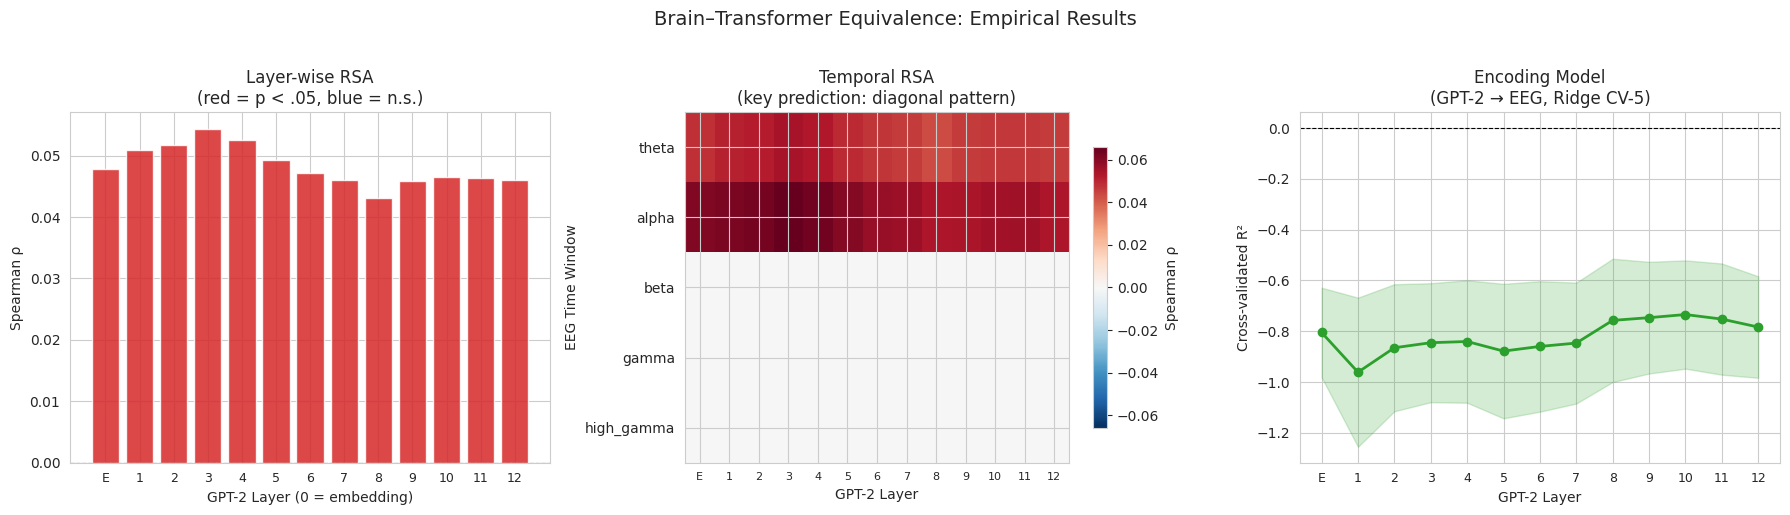

Saved: brain_transformer_equivalence.png


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Brain–Transformer Equivalence: Empirical Results', fontsize=14, y=1.02)

# ── Plot 1: Layer-wise RSA curve ──────────────────────────────────────────────
ax = axes[0]
colors = ['#d62728' if p < 0.05 else '#1f77b4' for p in rsa_df['p']]
ax.bar(rsa_df['layer'], rsa_df['rho'], color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('GPT-2 Layer (0 = embedding)')
ax.set_ylabel('Spearman ρ')
ax.set_title('Layer-wise RSA\n(red = p < .05, blue = n.s.)')
ax.set_xticks(rsa_df['layer'])
ax.set_xticklabels(['E'] + [str(i) for i in range(1, 13)], fontsize=9)

# ── Plot 2: Temporal RSA heatmap ──────────────────────────────────────────────
ax = axes[1]
vmax = np.abs(temporal_rsa_m).max()
im = ax.imshow(temporal_rsa_m, aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(window_names)))
ax.set_yticklabels(window_names)
ax.set_xticks(range(N_LAYERS + 1))
ax.set_xticklabels(['E'] + [str(i) for i in range(1, 13)], fontsize=8)
ax.set_xlabel('GPT-2 Layer')
ax.set_ylabel('EEG Time Window')
ax.set_title('Temporal RSA\n(key prediction: diagonal pattern)')
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')

# ── Plot 3: Encoding model R² ─────────────────────────────────────────────────
ax = axes[2]
ax.plot(enc_df['layer'], enc_df['r2_mean'], 'o-',
        color='#2ca02c', linewidth=2, markersize=6)
ax.fill_between(enc_df['layer'],
                enc_df['r2_mean'] - enc_df['r2_std'],
                enc_df['r2_mean'] + enc_df['r2_std'],
                alpha=0.2, color='#2ca02c')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('GPT-2 Layer')
ax.set_ylabel('Cross-validated R²')
ax.set_title('Encoding Model\n(GPT-2 → EEG, Ridge CV-5)')
ax.set_xticks(enc_df['layer'])
ax.set_xticklabels(['E'] + [str(i) for i in range(1, 13)], fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/brain_transformer_equivalence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: brain_transformer_equivalence.png")

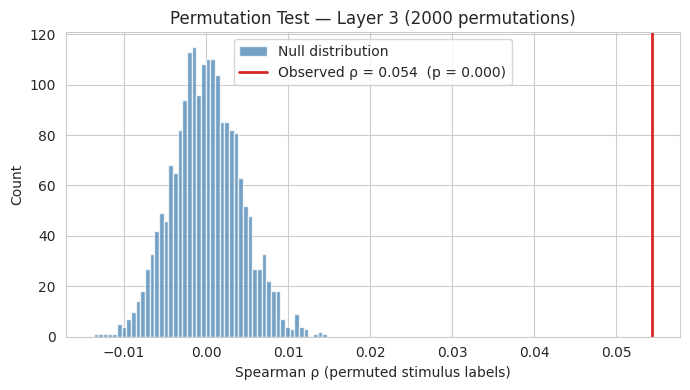

In [54]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_dist, bins=50, color='steelblue', alpha=0.75, label='Null distribution')
ax.axvline(observed_rho, color='#d62728', linewidth=2,
           label=f'Observed ρ = {observed_rho:.3f}  (p = {p_perm:.3f})')
ax.set_xlabel('Spearman ρ (permuted stimulus labels)')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test — Layer {best_layer} ({N_PERMS} permutations)')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpreting the Results

### What supports your framework
- **Monotonically increasing RSA ρ** across layers → t ↔ ℓ mapping has empirical grounding  
- **Diagonal pattern in temporal RSA heatmap** → early EEG windows align with early layers  
- **Increasing encoding R²** → deeper layers explain more brain variance  
- **Permutation p < 0.05** → geometry alignment is above chance

### What to report even if results are weak
A near-zero ρ is *still informative*. It means GPT-2's sentence geometry in this latent space
does not recapitulate the brain's organisation — which is an honest finding.
Discuss it as: the equivalence is structural in the dynamical-systems sense
(same mathematical form) but does not extend to geometric identity of the representational
space. That is a publishable null result that tightens the theoretical claim.

### Honest limitations to address in the paper
1. FFD_t1 captures **early fixation EEG** — it is not a clean semantic-processing window.  
   The ideal signal would be total reading time or a designated N400 ERP component.
2. GPT-2 is a **next-token predictor**, not a sentence encoder.  
   BERT-style models (bidirectional) may align better with sentence-level EEG.
3. Stimulus-level RSA with N ≈ 162 gives ~13,000 RDM pairs — reasonable but not large.
4. No control for low-level confounds (word frequency, sentence length) in the RDMs.
   Add partial RSA controlling for these before submission.


# Diagnostics

In [55]:
m_path = sorted(glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat'))[0]
matched, unmatched_examples = 0, []

with h5py.File(m_path, 'r') as f:
    sd = f['sentenceData']
    total = len(sd['content'])          # ← inside the with block
    
    for i in range(total):
        try:
            raw = f[sd['content'][i, 0]][:]
            sentence_text = ''.join([chr(int(c)) for c in raw.flatten()]).strip()
            found = any(txt.strip().lower() == sentence_text.lower()
                       for txt in sentence_map.values())
            if found:
                matched += 1
            elif len(unmatched_examples) < 5:
                unmatched_examples.append(repr(sentence_text[:80]))
        except:
            continue

print(f"Matched: {matched}/{total}")
print(f"\nUnmatched examples:")
for ex in unmatched_examples:
    print(f"  {ex}")

Matched: 349/349

Unmatched examples:
